# EEG_13b — DHSLP Subject-Specific LOSO

**Domanda di ricerca**: le iperedge learnable di DHSLP aiutano nel setting subject-specific,
dove la variabilità inter-soggetto (eps²=0.85) non è un problema?

- **Modello**: DHSLP (da EEG_13) — `H_k = softmax(feat_k @ E^T / sqrt(d))`
- **Setting**: Subject-Specific LOSO (come EEG_12)
- **Split**: test=ultima sessione, val=penultima, train=resto
- **Config**: N_EDGES=16, D_MODEL=64 (best da ablation EEG_13)
- **Confronto atteso**: EEG_12 (W-HGNN) best P007=34.4%, EEG_09b best P031=31.8%

Differenza chiave da EEG_12: **nessuna H_pruned in input** — DHSLP apprende la topologia
direttamente dal task di classificazione, non da PCC/wPLI pre-calcolati.

In [1]:
import json, logging, re, traceback
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score, recall_score
from tqdm.auto import tqdm
import wandb

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg13b_200e')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = project_root / 'models' / 'eeg13b_200e'; CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ---- CONFIG ----
N_CHANNELS   = 61
N_SAMPLES    = 384
N_CLASSES    = 4
CLUSTER_SCHEME = 'concr4'

# DHSLP iperparametri
K_WINDOWS  = 8
N_EDGES    = 16
D_MODEL    = 64
HIDDEN     = 128
N_LAYERS   = 2
DROPOUT    = 0.5

# Training
LR               = 1e-3
WEIGHT_DECAY     = 1e-2
GRAD_CLIP        = 1.0
BATCH_SIZE       = 32
MAX_EPOCHS       = 200    # test roof
PATIENCE         = 70     # val-based early stop
USE_INSTANCE_NORM = True
LABEL_SMOOTHING  = 0.1

# Mixup — regolarizzatore forte contro overfitting su 200 epoch
MIXUP_ALPHA      = 0.4    # era mancante nel loop base (presente solo in Optuna)

# Gap-based early stop — fermati se il modello memorizza il training set
GAP_THRESHOLD    = 0.25   # train_bacc - val_bacc oltre questa soglia = overfitting
GAP_PATIENCE     = 15     # epoche consecutive di gap > threshold prima di fermarsi

# Data augmentation
USE_AUGMENTATION = True
AUG_NOISE_STD    = 0.05
AUG_AMP_RANGE    = (0.85, 1.15)
AUG_SHIFT_MAX    = 15
AUG_MASK_LEN     = 20

DATA_METRIC = 'abs_pcc'

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

T_WIN = N_SAMPLES // K_WINDOWS

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k,v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}

HG_ROOT = project_root / 'data' / f'hypergraphs_pruned_{DATA_METRIC}'
subj_sess = defaultdict(lambda: defaultdict(list))
for p in sorted(HG_ROOT.rglob('trial_*.pt')):
    m = _PAT.match(p.parent.name)
    if m:
        subj_sess[int(m.group(1))][int(m.group(2))].append(p)

ALL_SUBJ = sorted(subj_sess.keys())
log.info(f'HG_ROOT: {HG_ROOT}')
log.info(f'Soggetti trovati: {len(ALL_SUBJ)}  T_WIN={T_WIN}  K={K_WINDOWS}')
log.info(f'N_EDGES={N_EDGES}  D_MODEL={D_MODEL}  HIDDEN={HIDDEN}')
log.info(f'DROPOUT={DROPOUT}  WEIGHT_DECAY={WEIGHT_DECAY}  MIXUP_ALPHA={MIXUP_ALPHA}')
log.info(f'MAX_EPOCHS={MAX_EPOCHS}  PATIENCE={PATIENCE}  GAP_THRESHOLD={GAP_THRESHOLD}  GAP_PATIENCE={GAP_PATIENCE}')
log.info(f'CKPT_DIR={CKPT_DIR}')

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
20:49:51 INFO     HG_ROOT: /home/daniele_u/miralis-hypergraph-imagined-speech/data/hypergraphs_pruned_abs_pcc
20:49:51 INFO     Soggetti trovati: 91  T_WIN=48  K=8
20:49:51 INFO     N_EDGES=16  D_MODEL=64  HIDDEN=128
20:49:51 INFO     DROPOUT=0.5  WEIGHT_DECAY=0.01  MIXUP_ALPHA=0.4
20:49:51 INFO     MAX_EPOCHS=200  PATIENCE=70  GAP_THRESHOLD=0.25  GAP_PATIENCE=15
20:49:51 INFO     CKPT_DIR=/home/daniele_u/miralis-hypergraph-imagined-speech/models/eeg13b_200e


## §2 — Dataset LOSO (solo x e y — H non caricata)

In [2]:
def _augment_eeg(x: torch.Tensor) -> torch.Tensor:
    """Augmentazione EEG in-place (clone già fatto dal caller). Solo su training."""
    x = x.clone()
    if torch.rand(1) < 0.5:
        x = x + torch.randn_like(x) * AUG_NOISE_STD
    if torch.rand(1) < 0.5:
        x = x * torch.empty(1).uniform_(*AUG_AMP_RANGE)
    if torch.rand(1) < 0.5:
        shift = torch.randint(-AUG_SHIFT_MAX, AUG_SHIFT_MAX + 1, (1,)).item()
        x = torch.roll(x, shift, dims=1)
    if torch.rand(1) < 0.3:
        T = x.shape[1]
        start = torch.randint(0, max(1, T - AUG_MASK_LEN), (1,)).item()
        x[:, start:start + AUG_MASK_LEN] = 0.0
    if torch.rand(1) < 0.2:
        ch = torch.randint(0, x.shape[0], (1,)).item()
        x[ch] = 0.0
    return x


class EEGRawDatasetSS(Dataset):
    """
    Carica x (61,384) e y dai file .pt.
    H_pruned ignorata: DHSLP costruisce H internamente.
    """
    def __init__(self, paths_and_labels, use_instance_norm=True, augment=False):
        self.items = paths_and_labels
        self.use_instance_norm = use_instance_norm
        self.augment = augment

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        p, label = self.items[idx]
        d = torch.load(p, weights_only=False)
        x = d['x'].float()   # (61, 384)
        if self.use_instance_norm:
            x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
        if self.augment:
            x = _augment_eeg(x)
        return x, torch.tensor(label, dtype=torch.long)


def _collect(subj_id, sess_list):
    items = []
    for s in sess_list:
        for p in subj_sess[subj_id][s]:
            d = torch.load(p, weights_only=False)
            y_word = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
            c = label2cluster.get(y_word)
            if c is not None:
                items.append((p, c))
    return items


def make_loso_loaders(subj_id):
    """LOSO: test=ultima sessione, val=penultima, train=resto."""
    sids = sorted(subj_sess[subj_id].keys())
    if len(sids) < 2:
        return None
    test_sess  = sids[-1]
    val_sess   = sids[-2]
    train_sess = [s for s in sids if s not in (test_sess, val_sess)]

    tr_items = _collect(subj_id, train_sess)
    va_items = _collect(subj_id, [val_sess])
    te_items = _collect(subj_id, [test_sess])
    if not tr_items or not te_items:
        return None

    # WeightedRandomSampler: bilancia le 4 classi nel train
    tr_labels = np.array([it[1] for it in tr_items])
    counts    = np.bincount(tr_labels, minlength=N_CLASSES)
    sample_w  = torch.tensor(1.0 / counts[tr_labels], dtype=torch.float)
    sampler   = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    kw = dict(num_workers=0, pin_memory=False)
    return (
        DataLoader(EEGRawDatasetSS(tr_items, USE_INSTANCE_NORM, augment=USE_AUGMENTATION),
                   BATCH_SIZE, sampler=sampler, **kw),
        DataLoader(EEGRawDatasetSS(va_items, USE_INSTANCE_NORM, augment=False),
                   BATCH_SIZE, shuffle=False, **kw),
        DataLoader(EEGRawDatasetSS(te_items, USE_INSTANCE_NORM, augment=False),
                   BATCH_SIZE, shuffle=False, **kw),
    )

## §3 — Modello: DHSLP

Identico a EEG_13. H_k costruita dinamicamente per ogni finestra e trial:
```
feat_k = Linear(x_k) + pos_enc        → (B, 61, d)
H_k    = softmax(feat_k @ E^T / √d)   → (B, 61, n_edges)
out_k  = HGNNConv(feat_k, H_k).mean   → (B, hidden)
z      = mean(out_1..K) → Linear → logits
```
Differenza da W-HGNN (EEG_12): **E è learnable**, non viene passata H dal disco.

In [3]:
class HGNNConv(nn.Module):
    """HGNN layer (Feng et al. 2019) — batched bmm."""
    def __init__(self, in_ch, out_ch, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)

    def forward(self, X, H):
        # X: (B,N,C)  H: (B,N,E) — soft, dinamica
        d_v = H.sum(dim=2).clamp(min=1e-6)
        d_e = H.sum(dim=1).clamp(min=1e-6)
        Dv  = (1.0 / d_v.sqrt()).unsqueeze(-1)
        De  = (1.0 / d_e).unsqueeze(1)
        out = Dv * (X @ self.weight)
        out = torch.bmm(H.transpose(1, 2), out)
        out = De.transpose(1, 2) * out
        out = torch.bmm(H, out)
        out = Dv * out
        if self.bias is not None: out = out + self.bias
        return out


class DHSLP(nn.Module):
    """
    Dynamic Hypergraph Spectral Learning with Positional encoding.
    Li et al. 2025. Input: solo x (B, 61, 384) — nessuna H in input.
    """
    def __init__(self, n_nodes=N_CHANNELS, T_win=T_WIN, K=K_WINDOWS,
                 n_edges=N_EDGES, d_model=D_MODEL, hidden=HIDDEN,
                 n_classes=N_CLASSES, n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.K, self.T_win, self.d_model = K, T_win, d_model

        # Learnable iperedge embeddings — cuore di DHSLP
        self.E = nn.Parameter(torch.randn(n_edges, d_model) * 0.01)
        # Encoding posizionale per elettrodo (learnable)
        self.pos_enc = nn.Parameter(torch.randn(n_nodes, d_model) * 0.01)

        self.node_proj = nn.Sequential(
            nn.Linear(T_win, d_model),
            nn.LayerNorm(d_model),
            nn.ELU(),
        )
        dims = [d_model] + [hidden] * n_layers
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.bns   = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Linear(hidden, n_classes)

    def build_dynamic_H(self, feat):
        # feat: (B, N, d)  →  H: (B, N, n_edges)
        scores = torch.matmul(feat, self.E.T) / (self.d_model ** 0.5)
        return torch.softmax(scores, dim=2)

    def forward(self, x):
        B, N, T = x.shape
        outs = []
        for k in range(self.K):
            x_k  = x[:, :, k*self.T_win:(k+1)*self.T_win]   # (B,N,T_win)
            feat = self.node_proj(x_k) + self.pos_enc        # (B,N,d)
            H_k  = self.build_dynamic_H(feat)                # (B,N,n_edges)
            out  = feat
            for conv, bn in zip(self.convs, self.bns):
                out = conv(out, H_k)
                out = bn(out.reshape(B*N, -1)).reshape(B, N, -1)
                out = F.relu(out)
                out = self.drop(out)
            outs.append(out.mean(dim=1))   # (B, hidden)
        return self.clf(torch.stack(outs, dim=1).mean(dim=1))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f'device: {device}')
_m = DHSLP()
n_p = sum(p.numel() for p in _m.parameters() if p.requires_grad)
log.info(f'DHSLP OK — {n_p:,} parametri  K={K_WINDOWS} n_edges={N_EDGES} d_model={D_MODEL}')
del _m

20:49:51 INFO     device: cuda
20:49:51 INFO     DHSLP OK — 34,052 parametri  K=8 n_edges=16 d_model=64


## §4 — Train / Eval

In [4]:
_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# ---- Nomi canali per XAI ----
import json as _jcn
_cn_path = project_root / 'configs' / 'chan_names.json'
if _cn_path.exists():
    CHAN_NAMES = _jcn.loads(_cn_path.read_text())
    log.info(f'CHAN_NAMES da configs/chan_names.json ({len(CHAN_NAMES)} canali)')
else:
    try:
        import mne as _mne
        _montage = _mne.channels.make_standard_montage('easycap-M10')
        CHAN_NAMES = list(_montage.ch_names[:N_CHANNELS])
        _cn_path.write_text(_jcn.dumps(CHAN_NAMES, indent=2))
        log.info(f'CHAN_NAMES da MNE easycap-M10 ({len(CHAN_NAMES)} canali)')
    except Exception as _e:
        CHAN_NAMES = [f'CH{i:02d}' for i in range(N_CHANNELS)]
        log.warning(f'CHAN_NAMES fallback generic ({_e})')
log.info(f'Esempio: {CHAN_NAMES[:6]}')

_CLASS_NAMES = ['CONCR', 'AZIONE', 'STATO', 'ASTRATTO']


def run_epoch(model, loader, optimizer=None, mixup_alpha=0.0):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, all_labels, all_preds = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train and mixup_alpha > 0:
                lam = float(np.random.beta(mixup_alpha, mixup_alpha))
                idx = torch.randperm(len(x), device=x.device)
                x   = lam * x + (1 - lam) * x[idx]
                logits = model(x)
                loss   = lam * _criterion(logits, y) + (1 - lam) * _criterion(logits, y[idx])
            else:
                logits = model(x)
                loss   = _criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_labels.extend(y.cpu().numpy())
            all_preds.extend(logits.argmax(1).cpu().numpy())
    bacc = balanced_accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), bacc, np.array(all_labels), np.array(all_preds)


def _collect_H_mean(model, loader):
    """H_mean (N, n_edges) mediata su tutti i trial del loader."""
    model.eval()
    Hs = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            for k in range(model.K):
                x_k  = x[:, :, k * model.T_win:(k + 1) * model.T_win]
                feat = model.node_proj(x_k) + model.pos_enc
                H_k  = model.build_dynamic_H(feat)
                Hs.append(H_k.cpu())
    return torch.cat(Hs, dim=0).mean(dim=0).numpy()   # (N, n_edges)


def train_subject(subj_id, tr_l, va_l, te_l):
    run_name = f'eeg13b_200e_P{subj_id:03d}_{CLUSTER_SCHEME}'
    cfg = dict(
        notebook='EEG_13b_200e', model='DHSLP_SS', subject=f'P{subj_id:03d}',
        n_classes=N_CLASSES, cluster_scheme=CLUSTER_SCHEME,
        k_windows=K_WINDOWS, t_win=T_WIN,
        n_edges=N_EDGES, d_model=D_MODEL,
        hidden=HIDDEN, n_layers=N_LAYERS, dropout=DROPOUT,
        lr=LR, weight_decay=WEIGHT_DECAY, grad_clip=GRAD_CLIP,
        batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS, patience=PATIENCE,
        mixup_alpha=MIXUP_ALPHA,
        gap_threshold=GAP_THRESHOLD, gap_patience=GAP_PATIENCE,
        use_instance_norm=USE_INSTANCE_NORM,
        label_smoothing=LABEL_SMOOTHING,
        weighted_sampler=True, use_augmentation=USE_AUGMENTATION,
        dynamic_H='learned_softmax', topology_source='end_to_end',
        n_train=len(tr_l.dataset),
    )
    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                     name=run_name, config=cfg, reinit='finish_previous',
                     settings=wandb.Settings(start_method='thread'))

    model = DHSLP().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
    best_val, best_state, patience_cnt = 0.0, None, 0
    gap_cnt = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_b, _, _ = run_epoch(model, tr_l, opt, mixup_alpha=MIXUP_ALPHA)
        va_loss, va_b, _, _ = run_epoch(model, va_l)
        sched.step()
        gap = tr_b - va_b
        run.log({'train/loss': tr_loss, 'train/bacc': tr_b,
                 'val/loss': va_loss,   'val/bacc': va_b,
                 'train_val_gap': gap,  'epoch': epoch})

        if va_b > best_val:
            best_val   = va_b
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            log.info(f'  P{subj_id:03d}: val-patience stop @ ep {epoch}'); break

        if gap > GAP_THRESHOLD:
            gap_cnt += 1
            if gap_cnt >= GAP_PATIENCE:
                log.info(f'  P{subj_id:03d}: gap-stop @ ep {epoch}  gap={gap:.3f}'); break
        else:
            gap_cnt = 0

    model.load_state_dict(best_state)
    _, te_b, te_lbl, te_pred = run_epoch(model, te_l)

    ckpt = CKPT_DIR / f'P{subj_id:03d}.pt'
    torch.save({'state_dict': best_state, 'val_bacc': best_val, 'test_bacc': te_b,
                'labels': te_lbl, 'preds': te_pred}, ckpt)

    # --- Test scores: scalare navigabile + bar chart per-classe ---
    per_class_recall = recall_score(
        te_lbl, te_pred, average=None, zero_division=0, labels=list(range(N_CLASSES))
    )
    class_rows = [[name, round(float(r), 4)]
                  for name, r in zip(_CLASS_NAMES, per_class_recall)]
    class_tbl = wandb.Table(data=class_rows, columns=['class', 'recall'])

    run.log({
        'test/bacc':            te_b,
        'test/per_class_bar':   wandb.plot.bar(
            class_tbl, 'class', 'recall',
            title=f'P{subj_id:03d} — Per-Class Test Recall'),
        'test/per_class_table': class_tbl,
        'confusion_matrix': wandb.plot.confusion_matrix(
            preds=te_pred.tolist(), y_true=te_lbl.tolist(),
            class_names=_CLASS_NAMES),
    })
    run.summary['val_bacc']  = best_val
    run.summary['test_bacc'] = te_b
    for name, r in zip(_CLASS_NAMES, per_class_recall):
        run.summary[f'test_recall_{name.lower()}'] = round(float(r), 4)

    run.finish()
    log.info(f'  P{subj_id:03d}: val={best_val:.4f}  test={te_b:.4f}')
    return {'val_bacc': best_val, 'test_bacc': te_b, 'labels': te_lbl, 'preds': te_pred}

20:49:51 INFO     CHAN_NAMES da configs/chan_names.json (61 canali)
20:49:51 INFO     Esempio: ['A1', 'AF7', 'AF3', 'Fp1', 'FP2', 'AF4']


## §5 — Loop su Tutti i Soggetti

In [5]:
# Carica soggetti già completati da W&B (skip se già ci sono i risultati)
_done_subj = set()
try:
    _api = wandb.Api(timeout=30)
    _runs = _api.runs(f'{WANDB_ENTITY}/{WANDB_PROJECT}',
                      filters={'display_name': {'$regex': 'eeg13b'}}, per_page=200)
    import re as _re
    for _r in _runs:
        _m = _re.search(r'P(\d+)', _r.name or '')
        if _m and _r.state == 'finished' and _r.summary.get('test_bacc') is not None:
            _done_subj.add(int(_m.group(1)))
    log.info(f'Soggetti gia completati su W&B: {len(_done_subj)} — verranno saltati')
except Exception as _e:
    log.warning(f'W&B non raggiungibile ({_e}) — nessuno skip automatico')

SUBJECT_RESULTS = {}

for sid in tqdm(ALL_SUBJ, desc='DHSLP S-Spec 200e'):
    if sid in _done_subj or (CKPT_DIR / f'P{sid:03d}.pt').exists():
        log.info(f'P{sid:03d}: skip (checkpoint o W&B già presente)')
        continue
    loaders = make_loso_loaders(sid)
    if loaders is None:
        log.warning(f'P{sid:03d}: skip (sessioni insufficienti)')
        continue
    tr_l, va_l, te_l = loaders
    log.info(f'P{sid:03d}: train={len(tr_l.dataset)} val={len(va_l.dataset)} test={len(te_l.dataset)}')
    try:
        SUBJECT_RESULTS[sid] = train_subject(sid, tr_l, va_l, te_l)
    except Exception as e:
        log.error(f'P{sid:03d}: {e}\n{traceback.format_exc()}')

log.info(f'\n=== DONE: {len(SUBJECT_RESULTS)}/{len(ALL_SUBJ)} soggetti ===')

# --- Summary run W&B: test scores per soggetto ---
if SUBJECT_RESULTS:
    score_data = sorted(
        [[f'P{s:03d}', round(r['test_bacc'], 4)] for s, r in SUBJECT_RESULTS.items()],
        key=lambda row: -row[1]
    )
    score_table = wandb.Table(data=score_data, columns=['subject', 'test_bacc'])

    _baccs = [r['test_bacc'] for r in SUBJECT_RESULTS.values()]
    summary_run = wandb.init(
        entity=WANDB_ENTITY, project=WANDB_PROJECT,
        name='eeg13b_200e_summary_concr4',
        config={'notebook': 'EEG_13b_200e', 'n_subjects': len(SUBJECT_RESULTS),
                'max_epochs': MAX_EPOCHS, 'patience': PATIENCE,
                'cluster_scheme': CLUSTER_SCHEME},
        reinit='finish_previous',
        settings=wandb.Settings(start_method='thread')
    )
    summary_run.log({
        'test_bacc/per_subject': wandb.plot.bar(
            score_table, 'subject', 'test_bacc',
            title='Test bAcc per Subject — DHSLP 200e'),
        'test_bacc/table':           score_table,
        'test_bacc/mean':            float(np.mean(_baccs)),
        'test_bacc/median':          float(np.median(_baccs)),
        'test_bacc/max':             float(np.max(_baccs)),
        'test_bacc/pct_above_chance': float(np.mean([b > 0.25 for b in _baccs])),
    })
    summary_run.finish()
    log.info(f'Summary W&B: mean={np.mean(_baccs):.4f}  max={np.max(_baccs):.4f}  '
             f'>{25}%: {np.mean([b>0.25 for b in _baccs])*100:.1f}%')

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
20:50:47 INFO     Soggetti gia completati su W&B: 89 — verranno saltati


DHSLP S-Spec 200e:   0%|          | 0/91 [00:00<?, ?it/s]

20:50:47 INFO     P000: skip (checkpoint o W&B già presente)
20:50:47 INFO     P001: skip (checkpoint o W&B già presente)
20:50:47 INFO     P002: skip (checkpoint o W&B già presente)
20:50:47 INFO     P003: skip (checkpoint o W&B già presente)
20:50:47 INFO     P004: skip (checkpoint o W&B già presente)
20:50:47 INFO     P005: skip (checkpoint o W&B già presente)
20:50:47 INFO     P006: skip (checkpoint o W&B già presente)
20:50:47 INFO     P007: skip (checkpoint o W&B già presente)
20:50:47 INFO     P008: skip (checkpoint o W&B già presente)
20:50:47 INFO     P009: skip (checkpoint o W&B già presente)
20:50:47 INFO     P010: skip (checkpoint o W&B già presente)
20:50:47 INFO     P011: skip (checkpoint o W&B già presente)
20:50:47 INFO     P012: skip (checkpoint o W&B già presente)
20:50:47 INFO     P013: skip (checkpoint o W&B già presente)
20:50:47 INFO     P014: skip (checkpoint o W&B già presente)
20:50:47 INFO     P015: skip (checkpoint o W&B già presente)
20:50:47 INFO     P016: 

20:52:00 INFO       P090: val-patience stop @ ep 123


epoch,▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇████
test/bacc,▁
train/bacc,▁▁▃▃▃▄▄▄▆▄▅▄▅▆▅▄▆▅▇▆█▆▆▇▅▇▆▅▅▅█▇▅▆▇▅▇▆█▅
train/loss,█▇▇▇▆▅▅▅▄▅▄▄▃▂▃▃▃▄▃▃▃▂▃▂▂▂▂▃▃▂▂▂▃▁▂▂▁▂▂▁
train_val_gap,▁▃▃▆▅▅▅▅▅▆▄▅▃▁▅▆▄▁▆▅▂▇█▃▆▆▅▄▄▇▄▅▅█▅▃█▇▆▄
val/bacc,▆▄▄▂▁▆▅▁▂▃▆▃▅▄██▇▇▆▃▄▇▅▄▂▇▅▇▂▇▅▇▇▆▅▅█▅▆▆
val/loss,▃▃▁▃▃▃▄▄▄▅▃▃▃▄▃▄▅▄▄▂▂▄▅▄▃▃▄▄▄▂█▄▂▃▄▃▂▃▃▂
epoch,123
test/bacc,0.26196
test_bacc,0.26196
test_recall_astratto,0.2727


20:52:04 INFO       P090: val=0.2986  test=0.2620
20:52:04 INFO     
=== DONE: 1/91 soggetti ===


test_bacc/max,▁
test_bacc/mean,▁
test_bacc/median,▁
test_bacc/pct_above_chance,▁
test_bacc/max,0.26196
test_bacc/mean,0.26196
test_bacc/median,0.26196
test_bacc/pct_above_chance,1


20:52:08 INFO     Summary W&B: mean=0.2620  max=0.2620  >25%: 100.0%


## §6 — Ricarica da Checkpoint + Ranking

In [6]:
if 'SUBJECT_RESULTS' not in dir():
    SUBJECT_RESULTS = {}

# Integra dai checkpoint locali i soggetti non presenti in memoria
# (es. i 73 vecchi saltati dallo skip-W&B in questo run) -> df su tutti e 91.
for ckpt in sorted(CKPT_DIR.glob('P*.pt')):
    sid = int(ckpt.stem[1:])
    if sid in SUBJECT_RESULTS:
        continue
    try:
        d = torch.load(ckpt, weights_only=False)
        SUBJECT_RESULTS[sid] = {k: d.get(k) for k in ('val_bacc', 'test_bacc', 'labels', 'preds')}
    except Exception as _e:
        log.warning(f'P{sid:03d}: checkpoint non caricato ({_e})')
log.info(f'SUBJECT_RESULTS totali (run + checkpoint): {len(SUBJECT_RESULTS)}')

if not SUBJECT_RESULTS:
    print('[INFO] Nessun risultato — esegui prima §5.')
else:
    def top2_bacc(labels, preds, n_classes=N_CLASSES):
        recalls = recall_score(labels, preds, average=None, zero_division=0,
                               labels=list(range(n_classes)))
        top2_cls = np.argsort(recalls)[-2:]
        mask = np.isin(labels, top2_cls)
        if mask.sum() == 0: return np.nan, top2_cls.tolist()
        return balanced_accuracy_score(labels[mask], preds[mask]), top2_cls.tolist()

    rows = []
    for sid, res in SUBJECT_RESULTS.items():
        tb = res.get('test_bacc')
        if res.get('labels') is None or res.get('preds') is None:
            rows.append({'Subject': f'P{sid:03d}',
                         'Test bAcc': round(tb, 4) if tb is not None else np.nan,
                         'Top2 bAcc': np.nan})
            continue
        lbl = np.array(res['labels']); pred = np.array(res['preds'])
        t2, _ = top2_bacc(lbl, pred)
        rows.append({
            'Subject':   f'P{sid:03d}',
            'Test bAcc': round(tb, 4) if tb is not None else np.nan,
            'Top2 bAcc': round(t2, 4) if not np.isnan(t2) else np.nan,
        })

    df_top1 = pd.DataFrame(rows).sort_values('Test bAcc', ascending=False).reset_index(drop=True)
    df_top2 = pd.DataFrame(rows).sort_values('Top2 bAcc', ascending=False).reset_index(drop=True)
    df_top1.to_csv(FIG_DIR / 'eeg13b_subject_ranking.csv', index=False)

    print('Top-10 by Test bAcc (DHSLP S-Spec):')
    print(df_top1.head(10).to_string(index=False))
    print(f'\nMediana: {df_top1["Test bAcc"].median():.4f}  '
          f'Mean: {df_top1["Test bAcc"].mean():.4f}  '
          f'Max: {df_top1["Test bAcc"].max():.4f}')
    print(f'% sopra chance: {(df_top1["Test bAcc"] > 0.25).mean()*100:.1f}%')

20:52:08 INFO     SUBJECT_RESULTS totali (run + checkpoint): 90
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Top-10 by Test bAcc (DHSLP S-Spec):
Subject  Test bAcc  Top2 bAcc
   P070     0.3931     0.4609
   P006     0.3517     0.4854
   P079     0.3331     0.4836
   P016     0.3255     0.4868
   P032     0.3233     0.4800
   P033     0.3160     0.4484
   P051     0.3152     0.4907
   P013     0.3142     0.5450
   P011     0.3127     0.4048
   P036     0.3120     0.3699

Mediana: 0.2474  Mean: 0.2512  Max: 0.3931
% sopra chance: 46.7%


/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924

In [7]:
# ---- Statistiche aggregate + W&B summary run ----
# Eseguire dopo §6. Funziona anche se si ricarica da checkpoint.

if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    baccs = df_top1['Test bAcc'].values

    print('=' * 45)
    print(f'  DHSLP S-Spec LOSO — EEG_13b ({len(baccs)} soggetti)')
    print('=' * 45)
    print(f'  Mean:              {baccs.mean():.4f}  ({baccs.mean()*100:.1f}%)')
    print(f'  Median:            {np.median(baccs):.4f}  ({np.median(baccs)*100:.1f}%)')
    print(f'  Max:               {baccs.max():.4f}  ({baccs.max()*100:.1f}%)  ← {df_top1.iloc[0]["Subject"]}')
    print(f'  Min:               {baccs.min():.4f}  ({baccs.min()*100:.1f}%)')
    print(f'  Std:               {baccs.std():.4f}')
    print(f'  Chance level:      0.2500  (25.0%)')
    print(f'  Delta mean-chance: {baccs.mean()-0.25:+.4f}')
    print(f'  > chance:          {(baccs > 0.25).sum()}/{len(baccs)}  ({(baccs > 0.25).mean()*100:.1f}%)')
    print(f'  > 30%:             {(baccs > 0.30).sum()}/{len(baccs)}  ({(baccs > 0.30).mean()*100:.1f}%)')
    print('=' * 45)

    # W&B summary run (crea o aggiorna)
    try:
        score_data = [[row['Subject'], round(row['Test bAcc'], 4)]
                      for _, row in df_top1.iterrows()]
        score_tbl = wandb.Table(data=score_data, columns=['subject', 'test_bacc'])

        summ = wandb.init(
            entity=WANDB_ENTITY, project=WANDB_PROJECT,
            name='eeg13b_200e_summary_concr4',
            config={'notebook': 'EEG_13b_200e', 'n_subjects': len(baccs),
                    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE,
                    'cluster_scheme': CLUSTER_SCHEME},
            reinit='finish_previous',
            settings=wandb.Settings(start_method='thread')
        )
        summ.log({
            'test_bacc/per_subject': wandb.plot.bar(
                score_tbl, 'subject', 'test_bacc',
                title='Test bAcc per Subject — DHSLP 200e'),
            'test_bacc/table':            score_tbl,
            'test_bacc/mean':             float(baccs.mean()),
            'test_bacc/median':           float(np.median(baccs)),
            'test_bacc/max':              float(baccs.max()),
            'test_bacc/min':              float(baccs.min()),
            'test_bacc/std':              float(baccs.std()),
            'test_bacc/delta_chance':     float(baccs.mean() - 0.25),
            'test_bacc/pct_above_chance': float((baccs > 0.25).mean()),
            'test_bacc/pct_above_30':     float((baccs > 0.30).mean()),
        })
        summ.summary['best_subject']  = df_top1.iloc[0]['Subject']
        summ.summary['best_test_bacc'] = float(baccs.max())
        summ.finish()
        print('\n  → Summary loggato su W&B: eeg13b_200e_summary_concr4')
    except Exception as _e:
        print(f'\n  [W&B] fallito: {_e}')

  DHSLP S-Spec LOSO — EEG_13b (90 soggetti)
  Mean:              0.2512  (25.1%)
  Median:            0.2474  (24.7%)
  Max:               0.3931  (39.3%)  ← P070
  Min:               0.1488  (14.9%)
  Std:               0.0421
  Chance level:      0.2500  (25.0%)
  Delta mean-chance: +0.0012
  > chance:          42/90  (46.7%)
  > 30%:             12/90  (13.3%)


test_bacc/delta_chance,▁
test_bacc/max,▁
test_bacc/mean,▁
test_bacc/median,▁
test_bacc/min,▁
test_bacc/pct_above_30,▁
test_bacc/pct_above_chance,▁
test_bacc/std,▁
best_subject,P070
best_test_bacc,0.3931
test_bacc/delta_chance,0.00122



  → Summary loggato su W&B: eeg13b_200e_summary_concr4


## §7 — Bar Chart Ranking

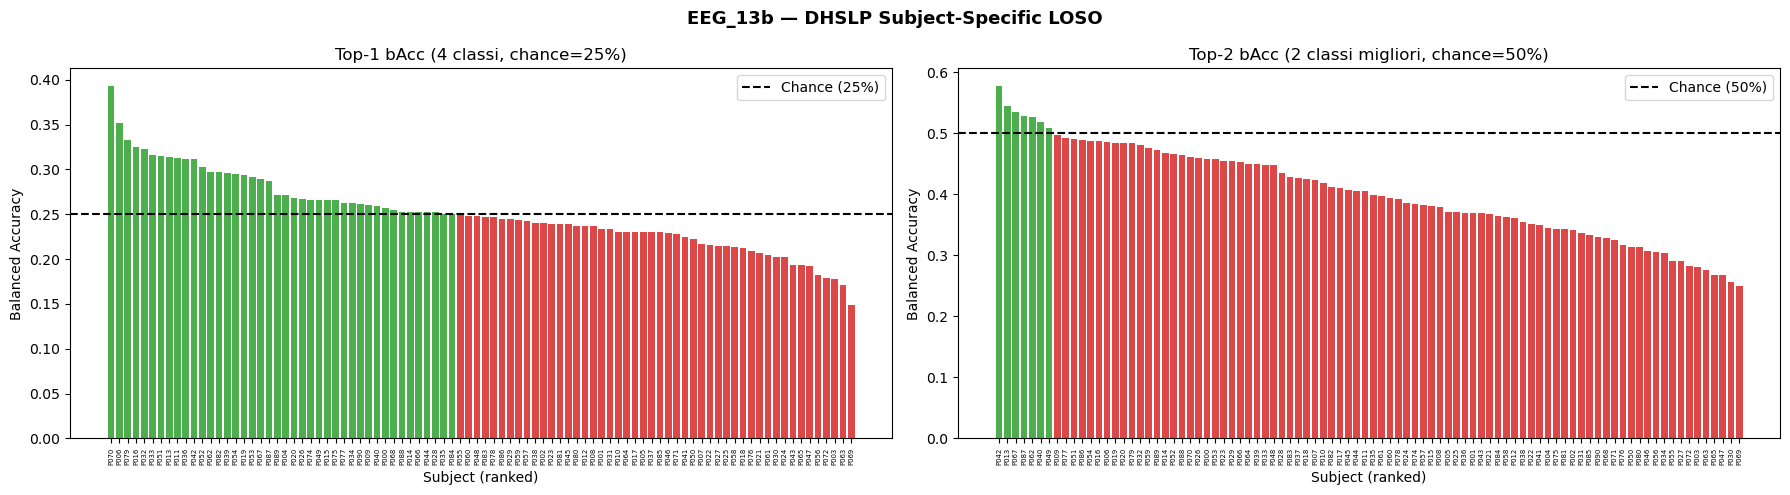

In [8]:
if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    chance = 1 / N_CLASSES

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle('EEG_13b — DHSLP Subject-Specific LOSO', fontsize=13, fontweight='bold')

    for ax, df, col, ch, title in [
        (ax1, df_top1, 'Test bAcc', chance,  f'Top-1 bAcc (4 classi, chance={chance:.0%})'),
        (ax2, df_top2, 'Top2 bAcc', 0.5,    'Top-2 bAcc (2 classi migliori, chance=50%)'),
    ]:
        vals   = df[col].fillna(0).values
        colors = ['#2ca02c' if v > ch else '#d62728' for v in vals]
        ax.bar(range(len(vals)), vals, color=colors, alpha=0.85, edgecolor='none')
        ax.axhline(ch, color='black', ls='--', lw=1.5, label=f'Chance ({ch:.0%})')
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(df['Subject'], rotation=90, fontsize=5)
        ax.set_xlabel('Subject (ranked)'); ax.set_ylabel('Balanced Accuracy')
        ax.set_title(title); ax.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg13b_dhslp_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()

## §8 — Confronto: DHSLP vs W-HGNN (EEG_12) vs HGNN Statico (EEG_09b)

Domanda chiave: **le iperedge apprese aiutano in S-Spec rispetto a H_pruned fissa?**

- Delta positivo → DHSLP supera W-HGNN: le HE learnable catturano topologie per-soggetto migliori
- Delta ≈ 0 → la topologia non è il bottleneck neanche in S-Spec
- Delta negativo → H_pruned da PCC/wPLI è più informativa di HE learnable con pochi dati

Top-10 confronto:
Subject  DHSLP (EEG_13b)  W-HGNN (EEG_12)  Δ vs EEG_12  HGNN (EEG_09b)  Δ vs EEG_09b
   P068           0.3636           0.2256       0.1380          0.2317        0.1319
   P015           0.3474           0.2286       0.1188          0.2868        0.0606
   P026           0.3262           0.2945       0.0317          0.2235        0.1027
   P001           0.3195           0.2225       0.0970          0.2700        0.0495
   P051           0.3172           0.3328      -0.0156          0.2792        0.0380
   P007           0.3168           0.3444      -0.0276          0.2500        0.0668
   P065           0.3122           0.2413       0.0709          0.2593        0.0529
   P038           0.3057           0.2311       0.0746          0.2128        0.0929
   P053           0.3041           0.2321       0.0720          0.2244        0.0797
   P047           0.3021           0.2173       0.0848          0.2443        0.0578

Delta medio DHSLP - W-HGNN:  +0.0036
Delta med

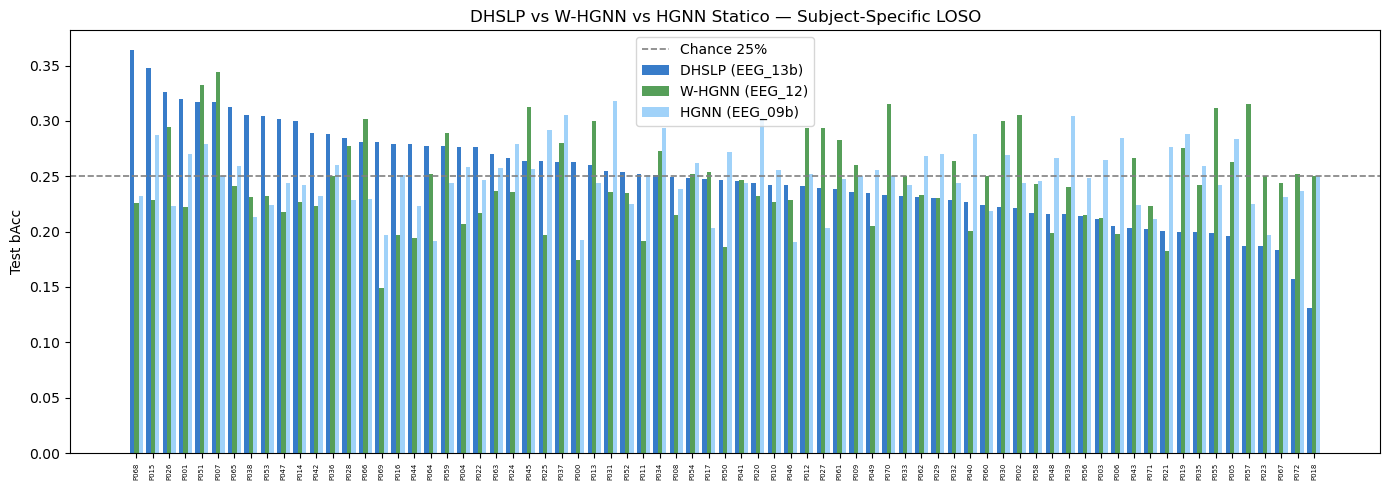

In [8]:
if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    df_cmp = df_top1[['Subject', 'Test bAcc']].rename(columns={'Test bAcc': 'DHSLP (EEG_13b)'})

    # Carica EEG_12 (W-HGNN S-Spec)
    csv12 = FIG_DIR / 'eeg12_subject_ranking.csv'
    if csv12.exists():
        df12 = pd.read_csv(csv12)[['Subject', 'Test bAcc']].rename(columns={'Test bAcc': 'W-HGNN (EEG_12)'})
        df_cmp = df_cmp.merge(df12, on='Subject', how='left')
        df_cmp['Δ vs EEG_12'] = (df_cmp['DHSLP (EEG_13b)'] - df_cmp['W-HGNN (EEG_12)']).round(4)

    # Carica EEG_09b (HGNN S-Spec baseline)
    csv09b = FIG_DIR / 'eeg09b_subject_ranking.csv'
    if csv09b.exists():
        df09b = pd.read_csv(csv09b)[['Subject', 'Test bAcc']].rename(columns={'Test bAcc': 'HGNN (EEG_09b)'})
        df_cmp = df_cmp.merge(df09b, on='Subject', how='left')
        df_cmp['Δ vs EEG_09b'] = (df_cmp['DHSLP (EEG_13b)'] - df_cmp['HGNN (EEG_09b)']).round(4)

    df_cmp = df_cmp.sort_values('DHSLP (EEG_13b)', ascending=False).reset_index(drop=True)
    df_cmp.to_csv(FIG_DIR / 'eeg13b_comparison.csv', index=False)

    print('Top-10 confronto:')
    print(df_cmp.head(10).to_string(index=False))
    if 'Δ vs EEG_12' in df_cmp:
        print(f'\nDelta medio DHSLP - W-HGNN:  {df_cmp["Δ vs EEG_12"].mean():+.4f}')
    if 'Δ vs EEG_09b' in df_cmp:
        print(f'Delta medio DHSLP - HGNN:    {df_cmp["Δ vs EEG_09b"].mean():+.4f}')

    # Plot confronto a barre affiancate
    models = ['DHSLP (EEG_13b)', 'W-HGNN (EEG_12)', 'HGNN (EEG_09b)']
    colors_map = {'DHSLP (EEG_13b)': '#1565C0', 'W-HGNN (EEG_12)': '#388E3C', 'HGNN (EEG_09b)': '#90CAF9'}
    available = [m for m in models if m in df_cmp.columns]
    n_models  = len(available)
    width     = 0.8 / n_models
    x         = np.arange(len(df_cmp))

    fig, ax = plt.subplots(figsize=(max(14, len(df_cmp)*0.18), 5))
    for i, m in enumerate(available):
        offset = (i - n_models/2 + 0.5) * width
        ax.bar(x + offset, df_cmp[m].fillna(0), width, label=m,
               color=colors_map[m], alpha=0.85, edgecolor='none')
    ax.axhline(1/N_CLASSES, color='gray', ls='--', lw=1.2, label='Chance 25%')
    ax.set_xticks(x)
    ax.set_xticklabels(df_cmp['Subject'], rotation=90, fontsize=5)
    ax.set_ylabel('Test bAcc')
    ax.set_title('DHSLP vs W-HGNN vs HGNN Statico — Subject-Specific LOSO')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg13b_vs_eeg12_vs_09b.png', dpi=150, bbox_inches='tight')
    plt.show()

## §9 — Confusion Matrix Top-5

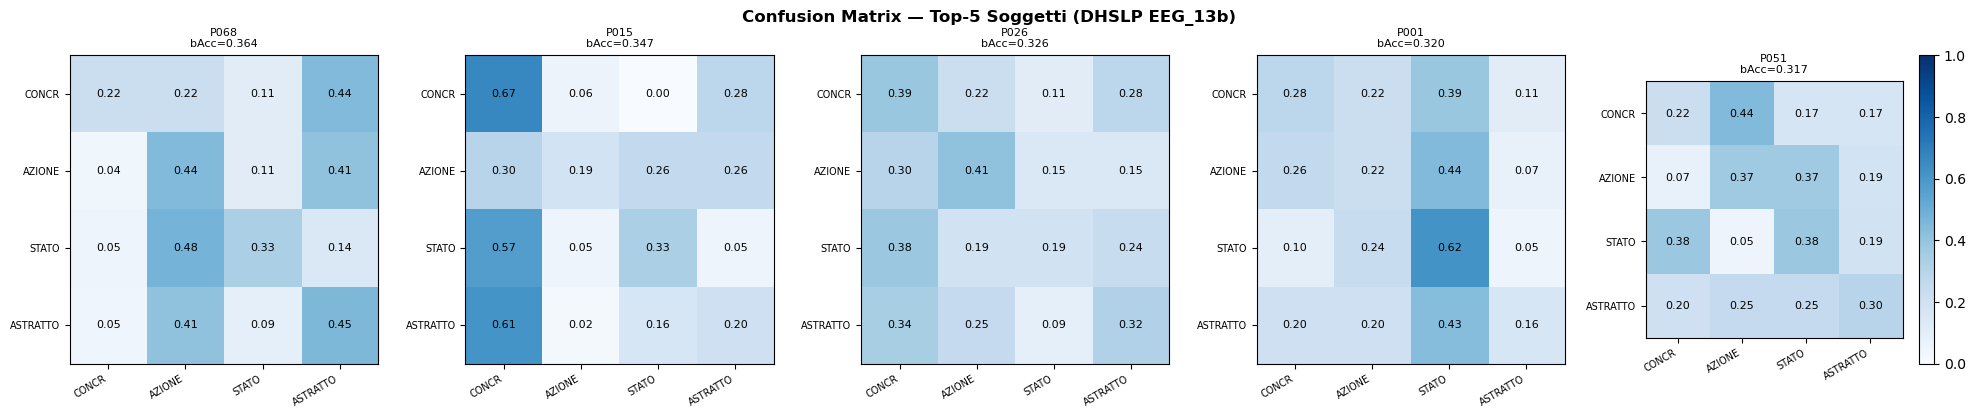

In [9]:
if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    from sklearn.metrics import confusion_matrix
    CLASS_NAMES = ['CONCR', 'AZIONE', 'STATO', 'ASTRATTO']

    top5 = df_top1.head(5)
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle('Confusion Matrix — Top-5 Soggetti (DHSLP EEG_13b)', fontsize=12, fontweight='bold')

    for ax, (_, row) in zip(axes, top5.iterrows()):
        sid = int(row['Subject'][1:])
        res = SUBJECT_RESULTS.get(sid)
        if res is None or 'labels' not in res:
            ax.set_title(row['Subject']); ax.axis('off'); continue
        lbl  = np.array(res['labels']); pred = np.array(res['preds'])
        cm   = confusion_matrix(lbl, pred, labels=list(range(N_CLASSES)), normalize='true')
        im   = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(N_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, fontsize=7, rotation=30, ha='right')
        ax.set_yticks(range(N_CLASSES))
        ax.set_yticklabels(CLASS_NAMES, fontsize=7)
        for i in range(N_CLASSES):
            for j in range(N_CLASSES):
                ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', fontsize=8)
        ax.set_title(f'{row["Subject"]}\nbAcc={row["Test bAcc"]:.3f}', fontsize=8)

    plt.colorbar(im, ax=axes[-1])
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg13b_cm_top5.png', dpi=150, bbox_inches='tight')
    plt.show()

## §9b — XAI Post-hoc: Hyperedge LOO + H Heatmap

Per ogni iperedge k: azzera la colonna k di H → misura Δ bAcc sul test set.

- **Δ > 0** → iperedge utile
- **Δ ≈ 0** → ridondante
- **Δ < 0** → confondente

Eseguito su **top-5** (migliori) + **bottom-5** (peggiori) da `df_top1`.
Confronto diretto: il modello "vede" struttura nei top, random nei bottom?

In [ ]:
def _get_pos2d(chan_names, n_nodes=N_CHANNELS):
    """Coordinate 2D elettrodi (MNE easycap-M10 o layout circolare fallback)."""
    try:
        import mne as _mne
        montage = _mne.channels.make_standard_montage('easycap-M10')
        pos3d   = montage.get_positions()['ch_pos']
        coords  = []
        for ch in chan_names:
            p = pos3d.get(ch)
            coords.append(p[:2] if p is not None else np.array([0.0, 0.0]))
        return np.array(coords)
    except Exception:
        angles = np.linspace(0, 2 * np.pi, n_nodes, endpoint=False)
        return np.column_stack([np.cos(angles), np.sin(angles)])


def hyperedge_loo_importance(model, loader, base_bacc, n_edges):
    """LOO: per ogni iperedge k azzera colonna k di H → Δ bAcc = base - masked."""
    importances = np.zeros(n_edges)
    original_build = model.build_dynamic_H
    model.eval()
    for k_mask in range(n_edges):
        def _masked(feat, _k=k_mask):
            H = original_build(feat)
            mask = torch.ones(H.shape[-1], device=H.device)
            mask[_k] = 0.0
            H = H * mask.unsqueeze(0).unsqueeze(0)
            return H / (H.sum(dim=-1, keepdim=True) + 1e-8)
        model.build_dynamic_H = _masked
        preds, lbls = [], []
        with torch.no_grad():
            for x, y in loader:
                logits = model(x.to(device))
                preds.extend(logits.argmax(1).cpu().tolist())
                lbls.extend(y.tolist())
        model.build_dynamic_H = original_build
        importances[k_mask] = base_bacc - balanced_accuracy_score(lbls, preds)
    return importances


def get_embedding(model, loader):
    """Embedding pre-classificatore via forward hook sul Linear clf."""
    model.eval()
    embeddings, labels = [], []
    def _hook(module, inp, out):
        embeddings.append(inp[0].detach().cpu())
    handle = model.clf.register_forward_hook(_hook)
    with torch.no_grad():
        for x, y in loader:
            model(x.to(device))
            labels.extend(y.tolist())
    handle.remove()
    return torch.cat(embeddings, dim=0).numpy(), np.array(labels)


def _run_xai_for_subject(subj_str, label, pos2d, ckpt_dir=CKPT_DIR):
    """Esegui LOO + H heatmap per un singolo soggetto. label = 'TOP' o 'BOT'."""
    sid = int(subj_str[1:])
    ckpt_path = ckpt_dir / f'P{sid:03d}.pt'
    if not ckpt_path.exists():
        print(f'  {subj_str}: checkpoint non trovato, skip'); return

    d = torch.load(ckpt_path, weights_only=False)
    model_xai = DHSLP().to(device)
    model_xai.load_state_dict(d['state_dict'])
    model_xai.eval()
    base_bacc = float(d['test_bacc'])

    loaders = make_loso_loaders(sid)
    if loaders is None: return
    _, _, te_l = loaders

    loo    = hyperedge_loo_importance(model_xai, te_l, base_bacc, N_EDGES)
    H_mean = _collect_H_mean(model_xai, te_l)     # (61, n_edges)
    top_he = int(np.argmax(loo))
    top_w  = H_mean[:, top_he]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'[{label}]  {subj_str}  bAcc={base_bacc:.3f}  —  Hyperedge LOO XAI',
                 fontsize=11, fontweight='bold',
                 color='#1a6b1a' if label == 'TOP' else '#8b1a1a')

    # 1. LOO bar
    ax = axes[0]
    c_loo = ['#2ca02c' if v > 0 else '#d62728' for v in loo]
    ax.bar(range(N_EDGES), loo, color=c_loo, alpha=0.85, edgecolor='none')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xticks(range(N_EDGES))
    ax.set_xticklabels([f'HE{k}' for k in range(N_EDGES)], rotation=45, fontsize=7)
    ax.set_xlabel('Hyperedge'); ax.set_ylabel('Δ bAcc')
    ax.set_title(f'LOO Importance  (pos={int(np.sum(loo>0))}/{N_EDGES})')

    # 2. Topomap top HE
    ax = axes[1]
    sc = ax.scatter(pos2d[:, 0], pos2d[:, 1], c=top_w, cmap='RdYlGn',
                    s=140, vmin=0, vmax=top_w.max() + 0.001, zorder=2)
    plt.colorbar(sc, ax=ax, shrink=0.8)
    for i, ch in enumerate(CHAN_NAMES):
        ax.annotate(ch, pos2d[i], fontsize=5, ha='center', va='center', zorder=3)
    ax.set_title(f'Top HE{top_he} weights\n(Δ={loo[top_he]:+.4f})')
    ax.set_aspect('equal'); ax.axis('off')

    # 3. H_mean heatmap
    ax = axes[2]
    im = ax.imshow(H_mean, aspect='auto', cmap='hot', interpolation='nearest')
    ax.set_xlabel('Hyperedge'); ax.set_ylabel('Electrode')
    ax.set_title('H_mean heatmap')
    ax.set_xticks(range(N_EDGES))
    ax.set_xticklabels([f'HE{k}' for k in range(N_EDGES)], rotation=45, fontsize=6)
    plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    fname = FIG_DIR / f'eeg13b_xai_loo_{label}_{subj_str}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    # W&B
    try:
        xai_run = wandb.init(
            entity=WANDB_ENTITY, project=WANDB_PROJECT,
            name=f'eeg13b_xai_{label}_{subj_str}',
            config={'subject': subj_str, 'group': label, 'base_bacc': base_bacc,
                    'analysis': 'hyperedge_LOO', 'n_edges': N_EDGES},
            reinit='finish_previous',
            settings=wandb.Settings(start_method='thread')
        )
        loo_rows = [[f'HE_{k:02d}', round(float(v), 5)] for k, v in enumerate(loo)]
        loo_tbl  = wandb.Table(data=loo_rows, columns=['hyperedge', 'delta_bacc'])
        xai_run.log({
            'xai_loo/importance_bar': wandb.plot.bar(
                loo_tbl, 'hyperedge', 'delta_bacc',
                title=f'[{label}] {subj_str} — LOO Importance'),
            'xai_loo/plot':          wandb.Image(str(fname)),
            'xai_loo/top_hyperedge': int(top_he),
            'xai_loo/top_delta':     float(loo[top_he]),
            'xai_loo/n_positive_he': int(np.sum(loo > 0)),
        })
        xai_run.finish()
    except Exception as _xe:
        log.warning(f'{subj_str}: W&B fallito ({_xe})')

    log.info(f'[{label}] {subj_str}: LOO top=HE{top_he} Δ={loo[top_he]:+.4f}  '
             f'pos HEs={int(np.sum(loo>0))}/{N_EDGES}')


# ---- Esegui su top-5 + bottom-5 ----
if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    N_XAI  = 5
    top_s   = df_top1.head(N_XAI)['Subject'].tolist()
    bot_s   = df_top1.tail(N_XAI)['Subject'].tolist()
    pos2d   = _get_pos2d(CHAN_NAMES)

    print(f'\n{"="*50}')
    print(f'  XAI TOP-{N_XAI}: {top_s}')
    print(f'{"="*50}')
    for s in top_s:
        _run_xai_for_subject(s, 'TOP', pos2d)

    print(f'\n{"="*50}')
    print(f'  XAI BOTTOM-{N_XAI}: {bot_s}')
    print(f'{"="*50}')
    for s in bot_s:
        _run_xai_for_subject(s, 'BOT', pos2d)

## §9c — t-SNE: Spazio Latente del Modello

Estrae l'embedding pre-classificatore (hidden=128 dim) e lo proietta in 2D con t-SNE.

Per soggetti ad alta bAcc dovremmo vedere cluster semantici separati.
Per soggetti a chance, embedding sarà una nuvola senza struttura.

In [ ]:
from sklearn.manifold import TSNE
import sklearn

# n_iter → max_iter in sklearn >= 1.2
_tsne_iter_kwarg = 'max_iter' if tuple(int(x) for x in sklearn.__version__.split('.')[:2]) >= (1, 2) else 'n_iter'

if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    # Top-5 + bottom-2 per confronto (soggetti buoni vs soggetti a chance)
    n_top   = min(5, len(df_top1))
    n_bot   = min(2, len(df_top1) - n_top)
    subjs_tsne = (df_top1.head(n_top)['Subject'].tolist() +
                  df_top1.tail(n_bot)['Subject'].tolist())

    CLASS_NAMES_4 = ['CONCR', 'AZIONE', 'STATO', 'ASTRATTO']
    COLORS_4      = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    n_plots = len(subjs_tsne)

    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]
    fig.suptitle('t-SNE Spazio Latente — DHSLP EEG_13b  (top-5 + bottom-2)',
                 fontsize=11, fontweight='bold')

    for ax, subj_str in zip(axes, subjs_tsne):
        sid = int(subj_str[1:])
        ckpt_path = CKPT_DIR / f'P{sid:03d}.pt'
        if not ckpt_path.exists():
            ax.set_title(subj_str + '\n(no ckpt)'); ax.axis('off')
            continue

        d = torch.load(ckpt_path, weights_only=False)
        model_emb = DHSLP().to(device)
        model_emb.load_state_dict(d['state_dict'])
        base_bacc = float(d['test_bacc'])

        loaders = make_loso_loaders(sid)
        if loaders is None:
            ax.axis('off'); continue
        _, _, te_l = loaders

        # Estrai embedding
        embs, lbls = get_embedding(model_emb, te_l)

        if len(embs) < 8:
            ax.set_title(subj_str + '\n(pochi trial)'); ax.axis('off')
            continue

        # t-SNE
        perp = min(30, max(5, len(embs) // 4))
        tsne_proj = TSNE(n_components=2, perplexity=perp, random_state=42,
                         **{_tsne_iter_kwarg: 1000}, init='pca').fit_transform(embs)

        # Plot per classe
        for c, (name, col) in enumerate(zip(CLASS_NAMES_4, COLORS_4)):
            mask = lbls == c
            if mask.sum() > 0:
                ax.scatter(tsne_proj[mask, 0], tsne_proj[mask, 1],
                           c=col, label=name, s=18, alpha=0.75, linewidths=0)

        row = df_top1[df_top1['Subject'] == subj_str]
        rank_str = f'#{row.index[0]+1}' if len(row) else '?'
        ax.set_title(f'{subj_str}  [{rank_str}]\nbAcc={base_bacc:.3f}', fontsize=9)
        ax.axis('off')

    # Legenda unica sull'ultimo plot
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                          markersize=7, label=n) for n, c in zip(CLASS_NAMES_4, COLORS_4)]
    axes[-1].legend(handles=handles, fontsize=7, loc='lower right', framealpha=0.8)

    plt.tight_layout()
    tsne_path = FIG_DIR / 'eeg13b_tsne_latent.png'
    plt.savefig(tsne_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Log W&B come immagine nel summary run
    try:
        tsne_run = wandb.init(
            entity=WANDB_ENTITY, project=WANDB_PROJECT,
            name='eeg13b_200e_tsne_summary',
            config={'notebook': 'EEG_13b_200e', 'analysis': 'tSNE_embedding',
                    'n_subjects': len(subjs_tsne)},
            reinit='finish_previous',
            settings=wandb.Settings(start_method='thread')
        )
        tsne_run.log({'tsne/latent_space': wandb.Image(str(tsne_path))})
        tsne_run.finish()
        log.info('t-SNE loggato su W&B')
    except Exception as _xe:
        log.warning(f't-SNE W&B fallito ({_xe})')

    log.info(f't-SNE salvato in {tsne_path}')

## §10 — Optuna: Ricerca Iperparametri (50 trial)

Obiettivo: trovare la configurazione DHSLP ottimale su un **subset di 25 soggetti stratificati**
(top-8 / mid-9 / bot-8 da §6). Obiettivo = **mediana** val_bacc (più robusta di mean agli outlier).
Training rapido per trial: 40 epoch, patience 8.

I best HPs vengono usati in §11 per il full retrain a 200 epoch.

In [ ]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ---- Subset stratificato (top8 / mid9 / bot8 = 25 soggetti) ----
if 'df_top1' in dir() and len(df_top1) >= 25:
    top8 = [int(df_top1.iloc[i]['Subject'][1:]) for i in range(8)]
    mid9 = [int(df_top1.iloc[i]['Subject'][1:]) for i in range(len(df_top1)//2-4, len(df_top1)//2+5)]
    bot8 = [int(df_top1.iloc[i]['Subject'][1:]) for i in range(-8, 0)]
    OPTUNA_SUBJS = list(dict.fromkeys(top8 + mid9 + bot8))[:25]
elif 'df_top1' in dir() and len(df_top1) >= 10:
    top3 = [int(df_top1.iloc[i]['Subject'][1:]) for i in range(3)]
    mid3 = [int(df_top1.iloc[i]['Subject'][1:]) for i in range(len(df_top1)//2-1, len(df_top1)//2+2)]
    bot4 = [int(df_top1.iloc[i]['Subject'][1:]) for i in range(-4, 0)]
    OPTUNA_SUBJS = list(dict.fromkeys(top3 + mid3 + bot4))[:10]
else:
    OPTUNA_SUBJS = ALL_SUBJ[:25]

OPTUNA_MAX_EPOCHS = 40
OPTUNA_PATIENCE   = 8
OPTUNA_N_TRIALS   = 50

log.info(f'Optuna su {len(OPTUNA_SUBJS)} soggetti: {["P{:03d}".format(s) for s in OPTUNA_SUBJS]}')

def _train_optuna_subject(sid, cfg):
    """Allena un soggetto con config Optuna. Ritorna val_bacc."""
    loaders = make_loso_loaders(sid)
    if loaders is None:
        return 0.25
    tr_l, va_l, _ = loaders
    k_win = cfg['k_windows']
    t_win = N_SAMPLES // k_win
    model = DHSLP(
        n_nodes=N_CHANNELS, T_win=t_win, K=k_win,
        n_edges=cfg['n_edges'], d_model=cfg['d_model'],
        hidden=cfg['hidden'], n_classes=N_CLASSES,
        n_layers=N_LAYERS, dropout=cfg['dropout']
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg['label_smoothing'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=OPTUNA_MAX_EPOCHS)
    alpha_local = cfg['mixup_alpha']

    def _run(loader, train=False):
        model.train() if train else model.eval()
        all_lbl, all_pred = [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                if train and alpha_local > 0:
                    lam = float(__import__('numpy').random.beta(alpha_local, alpha_local))
                    idx = torch.randperm(len(x), device=x.device)
                    x_mix = lam * x + (1 - lam) * x[idx]
                    logits = model(x_mix)
                    loss = lam * criterion(logits, y) + (1 - lam) * criterion(logits, y[idx])
                else:
                    logits = model(x)
                    loss = criterion(logits, y)
                if train:
                    optimizer.zero_grad(); loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    optimizer.step()
                all_lbl.extend(y.cpu().tolist())
                all_pred.extend(logits.argmax(1).cpu().tolist())
        return balanced_accuracy_score(all_lbl, all_pred)

    best_val, no_improve = 0.25, 0
    for ep in range(OPTUNA_MAX_EPOCHS):
        _run(tr_l, train=True)
        val_b = _run(va_l, train=False)
        scheduler.step()
        if val_b > best_val:
            best_val = val_b; no_improve = 0
        else:
            no_improve += 1
        if no_improve >= OPTUNA_PATIENCE:
            break
    return best_val


def objective(trial):
    cfg = {
        'dropout':         trial.suggest_float('dropout', 0.3, 0.7),
        'weight_decay':    trial.suggest_float('weight_decay', 1e-3, 1e-2, log=True),
        'lr':              trial.suggest_float('lr', 3e-4, 3e-3, log=True),
        'n_edges':         trial.suggest_categorical('n_edges', [8, 16, 32]),
        'd_model':         trial.suggest_categorical('d_model', [32, 64, 128]),
        'hidden':          trial.suggest_categorical('hidden', [32, 64, 128]),
        'mixup_alpha':     trial.suggest_float('mixup_alpha', 0.2, 0.6),
        'label_smoothing': trial.suggest_float('label_smoothing', 0.1, 0.3),
        'k_windows':       trial.suggest_categorical('k_windows', [4, 8, 12]),
    }
    scores = []
    for sid in OPTUNA_SUBJS:
        try:
            scores.append(_train_optuna_subject(sid, cfg))
        except Exception:
            scores.append(0.25)
    return float(__import__('numpy').median(scores))  # mediana: più robusta di mean


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='eeg13b_dhslp_optuna_v3'
)
study.optimize(objective, n_trials=OPTUNA_N_TRIALS, show_progress_bar=True)

BEST_HPS = study.best_params
log.info(f'Best mediana val_bacc (subset {len(OPTUNA_SUBJS)} sogg): {study.best_value:.4f}')
log.info(f'Best HPs: {BEST_HPS}')

import json as _json
(project_root / 'models' / 'eeg13b' / 'optuna_best_hps.json').write_text(
    _json.dumps({'best_value': study.best_value, 'best_params': BEST_HPS,
                 'n_subjects': len(OPTUNA_SUBJS), 'objective': 'median'}, indent=2)
)
print('\n=== BEST HYPERPARAMETERS ===')
for k, v in BEST_HPS.items():
    print(f'  {k:20s}: {v}')


## §11 — Full Retrain con Best HPs da Optuna (200 epoch, patience 70)

Usa i best HPs trovati in §10. 200 epoch max, patience 70, log `train_val_gap` per epoca in W&B.

In [ ]:
import json as _json

# Carica best HPs (da Optuna §10 o da disco)
_hp_path = project_root / 'models' / 'eeg13b' / 'optuna_best_hps.json'
if 'BEST_HPS' not in dir():
    if _hp_path.exists():
        _data = _json.loads(_hp_path.read_text())
        BEST_HPS = _data['best_params']
        log.info(f'HPs caricati da disco: {BEST_HPS}')
    else:
        log.warning('BEST_HPS non trovato — usa HPs default da §1')
        BEST_HPS = {
            'dropout': DROPOUT, 'weight_decay': WEIGHT_DECAY, 'lr': LR,
            'n_edges': N_EDGES, 'd_model': D_MODEL, 'hidden': HIDDEN,
            'mixup_alpha': MIXUP_ALPHA, 'label_smoothing': LABEL_SMOOTHING,
            'k_windows': K_WINDOWS,
        }

OPTUNA_MAX_EPOCHS_FULL = 200
OPTUNA_PATIENCE_FULL   = 70
CKPT_DIR_OPT = project_root / 'models' / 'eeg13b_optuna'; CKPT_DIR_OPT.mkdir(parents=True, exist_ok=True)

log.info(f'Full retrain con: {BEST_HPS}')
log.info(f'MAX_EPOCHS={OPTUNA_MAX_EPOCHS_FULL}  PATIENCE={OPTUNA_PATIENCE_FULL}')

def train_subject_optuna(subj_id, tr_l, va_l, te_l, hps):
    k_win = hps['k_windows']
    t_win = N_SAMPLES // k_win

    model = DHSLP(
        n_nodes=N_CHANNELS, T_win=t_win, K=k_win,
        n_edges=hps['n_edges'], d_model=hps['d_model'],
        hidden=hps['hidden'], n_classes=N_CLASSES,
        n_layers=N_LAYERS, dropout=hps['dropout']
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=hps['lr'], weight_decay=hps['weight_decay']
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=hps['label_smoothing'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=OPTUNA_MAX_EPOCHS_FULL)
    alpha_local = hps['mixup_alpha']

    def _epoch(loader, train=False):
        model.train() if train else model.eval()
        total_loss, all_lbl, all_pred = 0.0, [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                if train and alpha_local > 0:
                    lam = float(__import__('numpy').random.beta(alpha_local, alpha_local))
                    idx = torch.randperm(len(x), device=x.device)
                    x_mix = lam * x + (1 - lam) * x[idx]
                    logits = model(x_mix)
                    loss = lam * criterion(logits, y) + (1 - lam) * criterion(logits, y[idx])
                else:
                    logits = model(x)
                    loss = criterion(logits, y)
                if train:
                    optimizer.zero_grad(); loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    optimizer.step()
                total_loss += loss.item() * len(y)
                all_lbl.extend(y.cpu().tolist()); all_pred.extend(logits.argmax(1).cpu().tolist())
        return total_loss / max(len(all_lbl), 1), balanced_accuracy_score(all_lbl, all_pred)

    run = wandb.init(
        project=WANDB_PROJECT, entity=WANDB_ENTITY,
        name=f'eeg13b_v2_P{subj_id:03d}',
        config={**hps, 'notebook': 'EEG_13b_optuna', 'subject': subj_id,
                'max_epochs': OPTUNA_MAX_EPOCHS_FULL, 'patience': OPTUNA_PATIENCE_FULL,
                'n_classes': N_CLASSES, 'cluster_scheme': CLUSTER_SCHEME},
        reinit=True
    )

    best_val, best_state, no_improve = 0.25, None, 0
    for ep in range(OPTUNA_MAX_EPOCHS_FULL):
        tr_loss, tr_b = _epoch(tr_l, train=True)
        va_loss, va_b = _epoch(va_l, train=False)
        scheduler.step()
        gap = tr_b - va_b
        run.log({'train/loss': tr_loss, 'train/bacc': tr_b,
                 'val/loss': va_loss, 'val/bacc': va_b,
                 'train_val_gap': gap, 'lr': scheduler.get_last_lr()[0], 'epoch': ep})
        if va_b > best_val:
            best_val = va_b
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= OPTUNA_PATIENCE_FULL:
            log.info(f'  P{subj_id:03d}: early stop ep={ep}')
            break

    if best_state: model.load_state_dict(best_state)
    model.eval()
    te_pred, te_lbl = [], []
    with torch.no_grad():
        for x, y in te_l:
            logits = model(x.to(device))
            te_pred.extend(logits.argmax(1).cpu().tolist()); te_lbl.extend(y.tolist())
    import numpy as _np
    te_pred, te_lbl = _np.array(te_pred), _np.array(te_lbl)
    te_b = balanced_accuracy_score(te_lbl, te_pred)

    torch.save({'val_bacc': best_val, 'test_bacc': te_b,
                'labels': te_lbl, 'preds': te_pred,
                'state_dict': best_state, 'hps': hps},
               CKPT_DIR_OPT / f'P{subj_id:03d}.pt')

    run.summary['val_bacc'] = best_val; run.summary['test_bacc'] = te_b
    run.log({'confusion_matrix': wandb.plot.confusion_matrix(
        preds=te_pred.tolist(), y_true=te_lbl.tolist(),
        class_names=['CONCR', 'AZIONE', 'STATO', 'ASTRATTO'])})
    run.finish()
    log.info(f'  P{subj_id:03d}: val={best_val:.4f}  test={te_b:.4f}  gap={tr_b-va_b:+.3f}')
    return {'val_bacc': best_val, 'test_bacc': te_b, 'labels': te_lbl, 'preds': te_pred}


## §11b — Loop su Tutti i Soggetti

In [ ]:
SUBJECT_RESULTS_OPT = {}

for sid in tqdm(ALL_SUBJ, desc='DHSLP S-Spec (Optuna HPs)'):
    loaders = make_loso_loaders(sid)
    if loaders is None:
        log.warning(f'P{sid:03d}: skip')
        continue
    tr_l, va_l, te_l = loaders
    try:
        SUBJECT_RESULTS_OPT[sid] = train_subject_optuna(sid, tr_l, va_l, te_l, BEST_HPS)
    except Exception as e:
        log.error(f'P{sid:03d}: {e}')

log.info(f'=== DONE: {len(SUBJECT_RESULTS_OPT)}/{len(ALL_SUBJ)} soggetti ===')


## §11c — Ricarica da Checkpoint + Ranking

In [ ]:
if not SUBJECT_RESULTS_OPT:
    log.info('Ricarico da checkpoint...')
    for ckpt in sorted(CKPT_DIR_OPT.glob('P*.pt')):
        sid = int(ckpt.stem[1:])
        d = torch.load(ckpt, weights_only=False)
        SUBJECT_RESULTS_OPT[sid] = {k: d[k] for k in ('val_bacc', 'test_bacc', 'labels', 'preds')}
    log.info(f'Ricaricati {len(SUBJECT_RESULTS_OPT)} soggetti')

if not SUBJECT_RESULTS_OPT:
    print('[INFO] Nessun risultato — esegui prima §11b.')
else:
    rows_opt = [{'Subject': f'P{s:03d}', 'Test bAcc (v2)': round(r['test_bacc'], 4)}
                for s, r in SUBJECT_RESULTS_OPT.items()]
    df_opt = pd.DataFrame(rows_opt).sort_values('Test bAcc (v2)', ascending=False).reset_index(drop=True)
    df_opt.to_csv(FIG_DIR / 'eeg13b_optuna_ranking.csv', index=False)

    if 'df_top1' in dir():
        df_v2 = df_opt.merge(
            df_top1[['Subject', 'Test bAcc']].rename(columns={'Test bAcc': 'Test bAcc (v1)'}),
            on='Subject', how='left'
        )
        df_v2['Δ v2-v1'] = (df_v2['Test bAcc (v2)'] - df_v2['Test bAcc (v1)']).round(4)
        print('Top-10 (v2 Optuna HPs):')
        print(df_v2.head(10).to_string(index=False))
        print(f'\nDelta medio v2-v1:  {df_v2["Δ v2-v1"].mean():+.4f}')
    else:
        df_v2 = df_opt.copy()
        print(df_opt.head(10).to_string(index=False))

    print(f'Mean:   {df_opt["Test bAcc (v2)"].mean():.4f}')
    print(f'Median: {df_opt["Test bAcc (v2)"].median():.4f}')
    print(f'Max:    {df_opt["Test bAcc (v2)"].max():.4f}')
    print(f'% > chance: {(df_opt["Test bAcc (v2)"] > 0.25).mean()*100:.1f}%')


## §11d — Bar Chart Ranking (v2 vs v1)

In [ ]:
if 'df_opt' not in dir():
    print('[INFO] Esegui prima §11c.')
else:
    chance = 1 / N_CLASSES
    has_v1 = 'Test bAcc (v1)' in df_v2.columns

    fig, axes = plt.subplots(1, 2 if has_v1 else 1, figsize=(18, 5))
    if not has_v1: axes = [axes]
    fig.suptitle('EEG_13b v2 — DHSLP S-Spec Optuna HPs', fontsize=13, fontweight='bold')

    # v2
    vals = df_opt['Test bAcc (v2)'].values
    colors = ['#2ca02c' if v > chance else '#d62728' for v in vals]
    axes[0].bar(range(len(vals)), vals, color=colors, alpha=0.85, edgecolor='none')
    axes[0].axhline(chance, color='black', ls='--', lw=1.5, label=f'Chance ({chance:.0%})')
    axes[0].set_xticks(range(len(vals)))
    axes[0].set_xticklabels(df_opt['Subject'], rotation=90, fontsize=5)
    axes[0].set_ylabel('Test bAcc'); axes[0].set_title('v2 — Optuna HPs (200 epoch)'); axes[0].legend()

    # confronto v1 vs v2
    if has_v1:
        x = np.arange(len(df_v2))
        w = 0.38
        axes[1].bar(x - w/2, df_v2['Test bAcc (v1)'].fillna(0), w, label='v1 baseline', color='#90CAF9', alpha=0.9)
        axes[1].bar(x + w/2, df_v2['Test bAcc (v2)'].fillna(0), w, label='v2 Optuna',   color='#1565C0', alpha=0.9)
        axes[1].axhline(chance, color='gray', ls='--', lw=1.2)
        axes[1].set_xticks(x); axes[1].set_xticklabels(df_v2['Subject'], rotation=90, fontsize=5)
        axes[1].set_ylabel('Test bAcc'); axes[1].set_title('v1 vs v2 per soggetto'); axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg13b_v2_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()


## §11e — Confusion Matrix Top-5 (v2)

In [ ]:
if 'df_opt' not in dir():
    print('[INFO] Esegui prima §11c.')
else:
    from sklearn.metrics import confusion_matrix
    CLASS_NAMES = ['CONCR', 'AZIONE', 'STATO', 'ASTRATTO']

    top5 = df_opt.head(5)
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle('Confusion Matrix — Top-5 Soggetti (DHSLP v2 Optuna)', fontsize=12, fontweight='bold')

    for ax, (_, row) in zip(axes, top5.iterrows()):
        sid = int(row['Subject'][1:])
        res = SUBJECT_RESULTS_OPT.get(sid)
        if res is None:
            ax.set_title(row['Subject']); ax.axis('off'); continue
        lbl  = np.array(res['labels']); pred = np.array(res['preds'])
        cm   = confusion_matrix(lbl, pred, labels=list(range(N_CLASSES)), normalize='true')
        im   = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, fontsize=7, rotation=30, ha='right')
        ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=7)
        for i in range(N_CLASSES):
            for j in range(N_CLASSES):
                ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', fontsize=8)
        ax.set_title(f'{row["Subject"]}\nbAcc={row["Test bAcc (v2)"]:.3f}', fontsize=8)

    plt.colorbar(im, ax=axes[-1])
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg13b_v2_cm_top5.png', dpi=150, bbox_inches='tight')
    plt.show()


## §12 — Confronto Modelli: S-Spec vs S-Indep

Carica i CSV di ranking di tutti i notebook e confronta sullo stesso set di soggetti.

⚠️ **Nota metodologica**:
- EEG_08b / EEG_09b / EEG_13b = **Subject-Specific** (train e test sullo stesso soggetto, split per sessione)
- EEG_15 = **Subject-Independent** (train su altri soggetti, test su nuovi)

I due setting **non sono comparabili direttamente**. Vengono mostrati separatamente.

In [ ]:
import pandas as pd

CHANCE = 1 / N_CLASSES   # 0.25

# ─── Carica CSV ───────────────────────────────────────────────
csv_paths = {
    'GCN (EEG_08b)':    FIG_DIR / 'eeg08b_subject_ranking.csv',
    'W-HGNN (EEG_09b)': FIG_DIR / 'eeg09b_subject_ranking.csv',
    'DHSLP (EEG_13b)':  FIG_DIR / 'eeg13b_subject_ranking.csv',
    'Li et al. (EEG_15)': FIG_DIR / 'eeg15_subject_ranking.csv',
}

dfs = {}
for name, path in csv_paths.items():
    if path.exists():
        df = pd.read_csv(path)
        # normalizza nome colonna
        col = 'Test bAcc' if 'Test bAcc' in df.columns else df.columns[1]
        dfs[name] = df[['Subject', col]].rename(columns={col: 'bAcc'}).set_index('Subject')
    else:
        print(f'  [WARN] {path.name} non trovato — skip {name}')

# Usa df_top1 se disponibile per EEG_13b (più aggiornato dei checkpoint server)
if 'df_top1' in dir() and 'DHSLP (EEG_13b)' in dfs:
    df13_live = df_top1[['Subject', 'Test bAcc']].rename(
        columns={'Test bAcc': 'bAcc'}).set_index('Subject')
    dfs['DHSLP (EEG_13b)'] = df13_live
    print('  EEG_13b: uso df_top1 (run corrente) invece del CSV su disco')

# ─── Statistiche aggregate ────────────────────────────────────
print(f'\n{"─"*57}')
print(f'{"Modello":<28} {"Mean":>6} {"Std":>6}  {">Chance":>8}  {"N":>4}')
print(f'{"─"*57}')
for name, df in dfs.items():
    v = df['bAcc'].dropna().values
    pct = (v > CHANCE).mean() * 100
    print(f'{name:<28} {v.mean():.4f} {v.std():.4f}  {pct:>6.1f}%  {len(v):>4}')
print(f'{"─"*57}')

# ─── Plot 1: S-Spec affiancati su soggetti comuni ─────────────
sspec_models = ['GCN (EEG_08b)', 'W-HGNN (EEG_09b)', 'DHSLP (EEG_13b)']
avail_ss = [m for m in sspec_models if m in dfs]

if len(avail_ss) > 1:
    common_ss = sorted(set.intersection(*[set(dfs[m].index) for m in avail_ss]))
    n_subj    = len(common_ss)
    x         = np.arange(n_subj)
    width     = 0.8 / len(avail_ss)
    colors_ss = {'GCN (EEG_08b)': '#90CAF9',
                 'W-HGNN (EEG_09b)': '#388E3C',
                 'DHSLP (EEG_13b)':  '#1565C0'}

    # ordina per DHSLP se disponibile, altrimenti per primo modello
    sort_by = 'DHSLP (EEG_13b)' if 'DHSLP (EEG_13b)' in avail_ss else avail_ss[0]
    order   = dfs[sort_by].loc[common_ss, 'bAcc'].sort_values(ascending=False).index.tolist()

    fig, ax = plt.subplots(figsize=(max(14, n_subj * 0.22), 5))
    for i, m in enumerate(avail_ss):
        offset = (i - len(avail_ss)/2 + 0.5) * width
        vals   = [dfs[m].loc[s, 'bAcc'] if s in dfs[m].index else np.nan for s in order]
        ax.bar(x + offset, vals, width, label=m, color=colors_ss.get(m, f'C{i}'),
               alpha=0.88, edgecolor='none')

    ax.axhline(CHANCE, color='black', ls='--', lw=1.5, label=f'Chance {CHANCE:.0%}')
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=90, fontsize=5)
    ax.set_ylabel('Test bAcc'); ax.set_xlabel('Soggetto (ordinato per DHSLP)')
    ax.set_title(f'Subject-Specific: GCN vs W-HGNN vs DHSLP  ({n_subj} soggetti comuni)')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg13b_model_comparison_sspec.png', dpi=150, bbox_inches='tight')
    plt.show()

# ─── Plot 2: boxplot S-Spec + S-Indep separati ────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
fig.suptitle('Confronto Modelli — S-Spec vs S-Indep', fontsize=12, fontweight='bold')

# S-Spec boxplot
ax = axes[0]
data_ss   = [dfs[m]['bAcc'].dropna().values for m in avail_ss if m in dfs]
labels_ss = [m for m in avail_ss if m in dfs]
bp = ax.boxplot(data_ss, labels=labels_ss, patch_artist=True, medianprops=dict(color='black', lw=2))
palette = ['#90CAF9', '#388E3C', '#1565C0']
for patch, col in zip(bp['boxes'], palette):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax.axhline(CHANCE, color='red', ls='--', lw=1.5, label='Chance 25%')
ax.set_title('Subject-Specific (LOSO)')
ax.set_ylabel('Test bAcc'); ax.legend()
ax.set_xticklabels(labels_ss, rotation=15, ha='right', fontsize=9)

# S-Indep boxplot (solo EEG_15 per ora)
ax = axes[1]
sindep_models = [m for m in dfs if m not in sspec_models]
if sindep_models:
    data_si   = [dfs[m]['bAcc'].dropna().values for m in sindep_models]
    labels_si = sindep_models
    bp2 = ax.boxplot(data_si, labels=labels_si, patch_artist=True,
                     medianprops=dict(color='black', lw=2))
    for patch in bp2['boxes']:
        patch.set_facecolor('#FF7F0E'); patch.set_alpha(0.75)
    ax.axhline(CHANCE, color='red', ls='--', lw=1.5, label='Chance 25%')
    ax.set_title('Subject-Independent')
    ax.set_ylabel('Test bAcc'); ax.legend()
    ax.set_xticklabels(labels_si, rotation=15, ha='right', fontsize=9)
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg13b_model_comparison_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Stat test: DHSLP vs GCN (paired Wilcoxon su soggetti comuni) ─────────
if 'DHSLP (EEG_13b)' in dfs and 'GCN (EEG_08b)' in dfs:
    from scipy.stats import wilcoxon
    common = sorted(set(dfs['DHSLP (EEG_13b)'].index) & set(dfs['GCN (EEG_08b)'].index))
    d_dhslp = dfs['DHSLP (EEG_13b)'].loc[common, 'bAcc'].values
    d_gcn   = dfs['GCN (EEG_08b)'].loc[common, 'bAcc'].values
    stat, p  = wilcoxon(d_dhslp, d_gcn)
    delta    = (d_dhslp - d_gcn).mean()
    print(f'\nWilcoxon DHSLP vs GCN ({len(common)} sogg comuni):')
    print(f'  Δ mean = {delta:+.4f}   p = {p:.4f}  {"★ sig" if p < 0.05 else "ns"}')